# Principal Component Analysis (PCA) Benchmarking

In this notebook, we compare our custom-built PCA (using Eigendecomposition of the Covariance Matrix) against the `scikit-learn` implementation. We will reduce the 30-dimensional Breast Cancer dataset down to just 2 dimensions so we can visualize it on a 2D scatter plot.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

# Import our custom module
from classical_ml.unsupervised.pca import PCA as CustomPCA

In [2]:
# 1. Load Dataset (30 Features)
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Scale the data (CRUCIAL FOR PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original Data shape: {X_scaled.shape}")

Original Data shape: (569, 30)


1. Custom PCA
Projected Data shape: (569, 2)


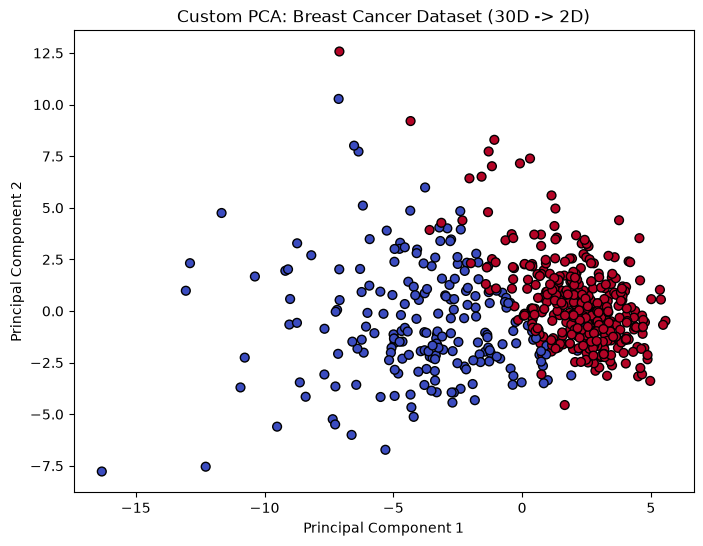

In [3]:
print("1. Custom PCA")

# Initialize PCA to reduce from 30 dimensions to 2 dimensions
custom_pca = CustomPCA(n_components=2)
X_projected_custom = custom_pca.fit_transform(X_scaled)

print(f"Projected Data shape: {X_projected_custom.shape}")

# Visualize the projection
plt.figure(figsize=(8, 6))
plt.scatter(X_projected_custom[:, 0], X_projected_custom[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Custom PCA: Breast Cancer Dataset (30D -> 2D)")
plt.show()

2. Scikit-Learn PCA


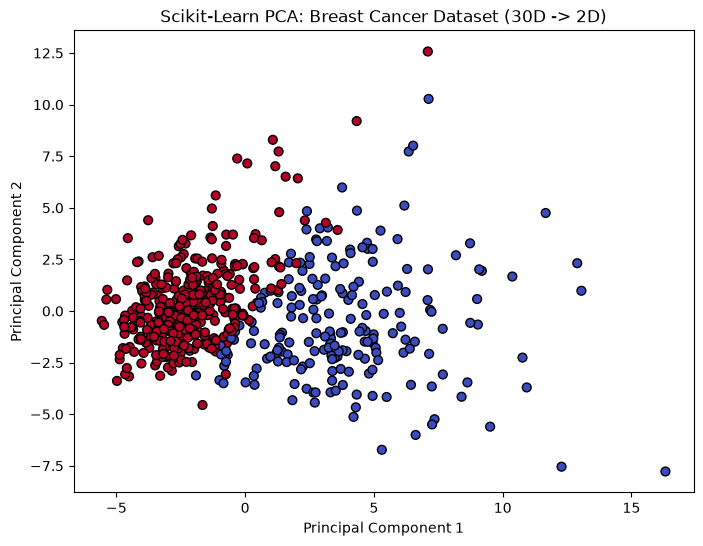

In [4]:
print("2. Scikit-Learn PCA")

sk_pca = SklearnPCA(n_components=2)
X_projected_sk = sk_pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_projected_sk[:, 0], X_projected_sk[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scikit-Learn PCA: Breast Cancer Dataset (30D -> 2D)")
plt.show()

## Conclusion
Both our custom PCA and `scikit-learn`'s PCA successfully reduced the 30-dimensional data into 2 dimensions while preserving enough variance to clearly separate the two classes (Malignant vs Benign).

**Important Mathematical Note (Eigenvector Sign Invariance):**
If you notice that the plots look like mirrored versions of each other (flipped on the X or Y axis). This is mathematically correct. The Eigenvectors (Principal Components) specify a *direction* (a line). Multiplying an eigenvector by $-1$ simply flips its direction but it still represents the exact same line in space. `scikit-learn` uses an algorithm called SVD (Singular Value Decomposition) which might flip the signs differently than our `np.linalg.eigh` approach, but the underlying projection holds the exact same structural information!